In [13]:
import datetime
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [18]:
data = pd.read_csv('Preprocessed/Preprocessed_data.csv')
data.head()

,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1,MatchID
0,2017-08-12,Premier League,Sat,Away,W,Manchester City,Brighton,1.9,0.3,77.0,...,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0,#Adelaide UtdSydney
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0,#Melb VictorySydney
2,2017-08-26,Premier League,Sat,Away,W,Manchester City,Bournemouth,1.4,0.5,70.0,...,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0,#SydneyW Sydney
3,2017-09-09,Premier League,Sat,Home,W,Manchester City,Liverpool,2.4,0.7,66.0,...,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0,#BrisbaneSydney
4,2017-09-13,Champions Lg,Wed,Away,W,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0,#SydneyW Sydney


In [21]:
for index, row in data.iterrows():
    if row['Venue'] == 'Home' and row['Result'] == 'W':
        data.loc[index, 'Result'] = 'H'
    elif row['Venue'] == 'Home' and row['Result'] == 'L':
        data.loc[index, 'Result'] = 'A'
    elif row['Venue'] == 'Away' and row['Result'] == 'W':
        data.loc[index, 'Result'] = 'A'
    elif row['Venue'] == 'Away' and row['Result'] == 'L':
        data.loc[index, 'Result'] = 'H'
    else:
        data.loc[index, 'Result'] = 'D'
        

In [22]:
data.Result.value_counts()

Result
H    11763
A     8336
D     6688
Name: count, dtype: int64

In [23]:
data.head()

,Date,Comp,Day,Venue,Result,Team,Opponent,xG,xGA,Poss,...,O_Fld.2,O_Off.1,O_Crs.1,O_Int.1,O_TklW.1,O_PKwon,O_PKcon,O_OG,O_Lost.1,MatchID
0,2017-08-12,Premier League,Sat,Away,A,Manchester City,Brighton,1.9,0.3,77.0,...,8.0,6.0,8.0,12.0,8.0,0.0,0.0,1.0,13.0,#Adelaide UtdSydney
1,2017-08-21,Premier League,Mon,Home,D,Manchester City,Everton,1.1,0.6,64.0,...,7.0,3.0,9.0,16.0,12.0,0.0,0.0,0.0,22.0,#Melb VictorySydney
2,2017-08-26,Premier League,Sat,Away,A,Manchester City,Bournemouth,1.4,0.5,70.0,...,14.0,0.0,9.0,12.0,13.0,0.0,0.0,0.0,23.0,#SydneyW Sydney
3,2017-09-09,Premier League,Sat,Home,H,Manchester City,Liverpool,2.4,0.7,66.0,...,10.0,2.0,9.0,18.0,12.0,0.0,0.0,0.0,9.0,#BrisbaneSydney
4,2017-09-13,Champions Lg,Wed,Away,A,Manchester City,nl Feyenoord,1.3,0.3,71.0,...,9.0,3.0,8.0,13.0,9.0,0.0,0.0,0.0,14.0,#SydneyW Sydney


In [24]:
data = pd.get_dummies(data, columns=['Venue', 'Day', 'Team', 'Opponent',
                      'Captain', 'Formation', 'Referee', 'Comp', 'MatchID'], dtype=int)
encoded_names = data.columns.tolist()
# encoded_names

In [5]:
# def ForFutureMatches(data):
#     data = pd.get_dummies(data, columns=[
#                           'Venue', 'Day', 'Team', 'Opponent', 'Captain', 'Formation', 'Referee', 'Comp'], dtype=int)
#     data['FTR'] = np.where(data['Result'] == 'W', 1, np.where(
#         data['Result'] == 'D', 0, np.where(data['Result'] == 'L', 2, np.nan)))
#     data.drop('Result', axis=1, inplace=True)
#     data['weight'] = 1
#     return data

In [26]:
data['FTR'] = np.where(data['Result'] == 'H', 0, np.where(

    data['Result'] == 'D', 1, np.where(data['Result'] == 'A', 2, np.nan)))

data.drop('Result', axis=1, inplace=True)

In [27]:
data.FTR.value_counts()

FTR
0.0    11763
2.0     8336
1.0     6688
Name: count, dtype: int64

In [28]:
data['Date'] = pd.to_datetime(data['Date'])


def get_weights(data):
    now = datetime.datetime.now()
    weight = 1.0 / (1 + (now - data['Date']).dt.days / 365)
    return weight


data['weight'] = get_weights(data)
data.head()

,Date,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,...,MatchID_#Wolfsburgua Shakhtar,MatchID_#Wolveses Espanyol,MatchID_#Wolveses Sevilla,MatchID_#Wolvesgr Olympiacos,MatchID_#Wolvespt Braga,MatchID_#Wolvessk Slovan Bratislava,MatchID_#Wolvestr Beşiktaş,MatchID_#Zulte Waregemnl Vitesse,FTR,weight
0,2017-08-12,1.9,0.3,77.0,30415.0,4.0,0.07,0.25,19.5,0.0,...,0,0,0,0,0,0,0,0,2.0,0.131864
1,2017-08-21,1.1,0.6,64.0,49108.0,6.0,0.05,0.17,20.0,0.0,...,0,0,0,0,0,0,0,0,1.0,0.132294
2,2017-08-26,1.4,0.5,70.0,10419.0,8.0,0.11,0.25,16.2,0.0,...,0,0,0,0,0,0,0,0,2.0,0.132534
3,2017-09-09,2.4,0.7,66.0,54172.0,10.0,0.38,0.50,14.0,0.0,...,0,0,0,0,0,0,0,0,0.0,0.133212
4,2017-09-13,1.3,0.3,71.0,43500.0,7.0,0.36,0.57,14.4,0.0,...,0,0,0,0,0,0,0,0,2.0,0.133406


In [29]:
means = data.mean()
data.fillna(means, inplace=True)
data.dropna(inplace=True)

ss = MinMaxScaler()
data.iloc[:,1:-2] = ss.fit_transform(data.iloc[:,1:-2])

In [31]:
x_train, x_test, y_train, y_test = train_test_split(data.drop(['FTR', 'Date'], axis=1), data['FTR'], random_state=42, test_size=0.1)

In [8]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acs = accuracy_score(y_test, y_pred)

c:\Users\moomad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
acs

0.9316909294512878

In [10]:
conma = confusion_matrix(y_test, y_pred)
conma

array([[1376,   29,   10],
       [  55,  619,   33],
       [   9,   47,  501]], dtype=int64)

In [11]:
clf = classification_report(y_test, y_pred)
print(clf)

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.96      1415
         1.0       0.89      0.88      0.88       707
         2.0       0.92      0.90      0.91       557

    accuracy                           0.93      2679
   macro avg       0.92      0.92      0.92      2679
weighted avg       0.93      0.93      0.93      2679



Deep Learning Model

In [ ]:
# weights = x_train['weight']
# x_train.drop('weight', axis = 1)
# x_test.drop('weight', axis = 1)

In [35]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_test

array([[1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       ...,
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.]], dtype=float32)

In [36]:
x_train.head()

,xG,xGA,Poss,Attendance,SoT,G/Sh,G/SoT,Dist,PK,xG.1,...,MatchID_#Wolfsburgua FC Oleksandriya,MatchID_#Wolfsburgua Shakhtar,MatchID_#Wolveses Espanyol,MatchID_#Wolveses Sevilla,MatchID_#Wolvesgr Olympiacos,MatchID_#Wolvespt Braga,MatchID_#Wolvessk Slovan Bratislava,MatchID_#Wolvestr Beşiktaş,MatchID_#Zulte Waregemnl Vitesse,weight
20709,0.065934,0.350000,0.784615,0.128132,0.181818,0.00,0.00,0.507003,0.000000,0.065934,...,0,0,0,0,0,0,0,0,0,0.691288
15134,0.428571,0.083333,0.430769,0.188091,0.227273,0.18,0.60,0.372549,0.333333,0.428571,...,0,0,0,0,0,0,0,0,0,0.285826
8398,0.274725,0.183333,0.600000,0.128132,0.090909,0.07,0.50,0.299720,0.000000,0.274725,...,0,0,0,0,0,0,0,0,0,0.248977
7125,0.043956,0.316667,0.569231,0.054473,0.045455,0.13,1.00,0.422969,0.000000,0.043956,...,0,0,0,0,0,0,0,0,0,0.194356
2898,0.153846,0.300000,0.461538,0.015950,0.363636,0.23,0.38,0.470588,0.000000,0.153846,...,0,0,0,0,0,0,0,0,0,0.169060


In [47]:

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

# model = Sequential()
# model.add(Dense(256, activation='relu', input_shape=(x_train.shape[1],)))
# model.add(BatchNormalization())
# model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.5))
# model.add(Dense(64, activation='softmax'))
# model.add(Dropout(0.5))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(3, activation='softmax'))
# #  this is good
# model.compile(optimizer='Adamax',
#               loss='categorical_crossentropy', metrics=['accuracy'])
# history = model.fit(x_train, y_train, epochs=30,
#                     batch_size=32, validation_data=(x_test, y_test))

In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import accuracy_score

# Define your Keras model as a function


def create_model(optimizer='adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(256, activation=activation,
              input_shape=(x_train.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dense(128, activation=activation))
    model.add(Dense(64, activation=activation))
    model.add(Dense(32, activation=activation))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Create KerasClassifier wrapper for GridSearchCV compatibility
model = KerasClassifier(build_fn=create_model,
                        activation='relu', dropout_rate=0.0, verbose=0)

# Define the grid search parameters
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Access best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)
print("Best error score: ", grid_search.error_score)


# Predict on test set using the best model
y_pred = grid_search.predict(x_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy: ", accuracy)

In [48]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [49]:
history = model.fit(x_train, y_train, epochs=50,
                    batch_size=64, validation_data=(x_test, y_test))

Epoch 1/50
377/377 [==============================] - 6s 11ms/step - loss: 0.9097 - accuracy: 0.5331 - val_loss: 0.7203 - val_accuracy: 0.7040
Epoch 2/50
377/377 [==============================] - 3s 9ms/step - loss: 0.6715 - accuracy: 0.6810 - val_loss: 0.5145 - val_accuracy: 0.7798
Epoch 3/50
377/377 [==============================] - 3s 8ms/step - loss: 0.5961 - accuracy: 0.7435 - val_loss: 0.4874 - val_accuracy: 0.8626
Epoch 4/50
377/377 [==============================] - 3s 9ms/step - loss: 0.5404 - accuracy: 0.7798 - val_loss: 0.4230 - val_accuracy: 0.8656
Epoch 5/50
377/377 [==============================] - 4s 10ms/step - loss: 0.5104 - accuracy: 0.7959 - val_loss: 0.3966 - val_accuracy: 0.8843
Epoch 6/50
377/377 [==============================] - 4s 9ms/step - loss: 0.4820 - accuracy: 0.8102 - val_loss: 0.3954 - val_accuracy: 0.8813
Epoch 7/50
377/377 [==============================] - 4s 10ms/step - loss: 0.4685 - accuracy: 0.8128 - val_loss: 0.3844 - val_accuracy: 0.8906
Epo

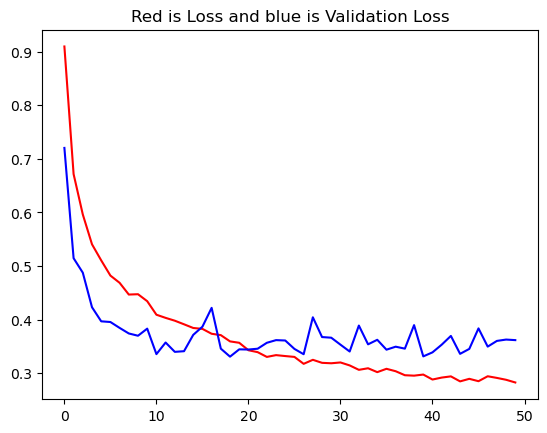

In [52]:
plt.plot(history.history['loss'], color='red')
plt.title("Red is Loss and blue is Validation Loss")
plt.plot(history.history['val_loss'], color='blue')

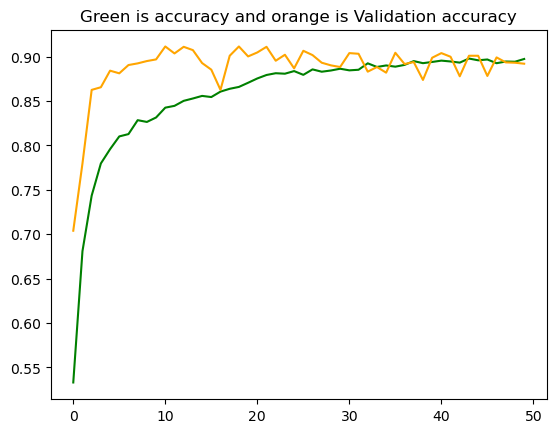

In [53]:
plt.plot(history.history['accuracy'], color='green', label='Train Data')
plt.title("Green is accuracy and orange is Validation accuracy")
plt.plot(history.history['val_accuracy'], color='orange', label='Validation Data')

In [54]:
model.save('FinalData.h5', 'wb')

c:\Users\moomad\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
nl = data.columns.to_list()

In [ ]:
import seaborn as sns
for i in data.columns.to_list():
    print(f'Plot for {i} at below' )
    sns.histplot(data[i])
    plt.show()